# 05 — SHAP Explainability

In [1]:
import pickle, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with open('../models/train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, feature_names = pickle.load(f)

best_model = joblib.load('../models/best_model.pkl')
print('Model loaded:', type(best_model).__name__)

Model loaded: LogisticRegression


In [2]:
# Create SHAP explainer
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)
print('SHAP values computed!')

SHAP values computed!


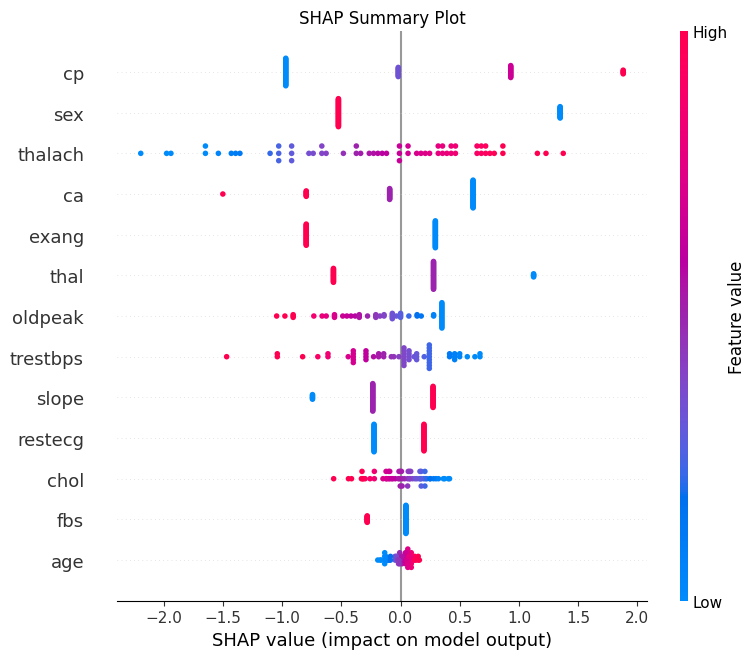

Saved shap_summary.png


In [3]:
# Summary plot — feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('../report/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_summary.png')

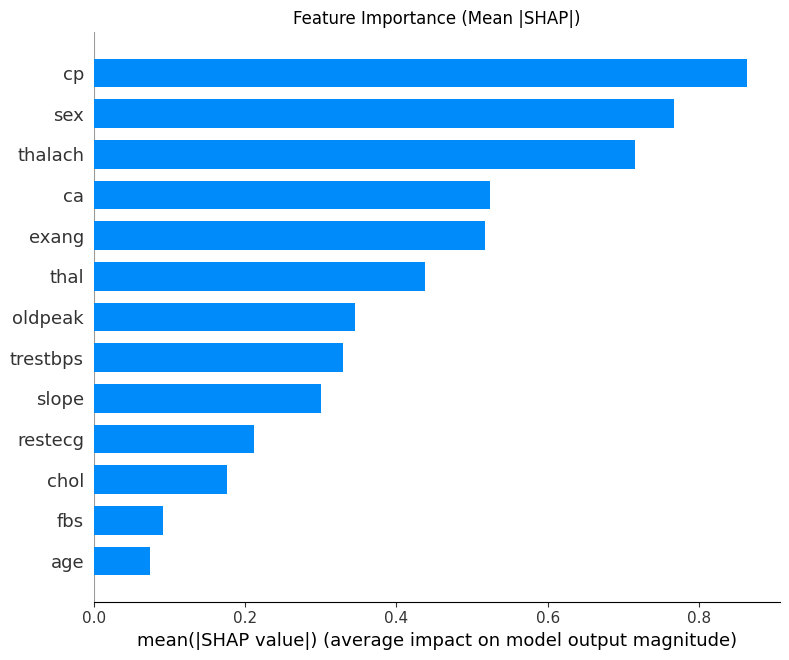

In [4]:
# Bar plot — mean absolute SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig('../report/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

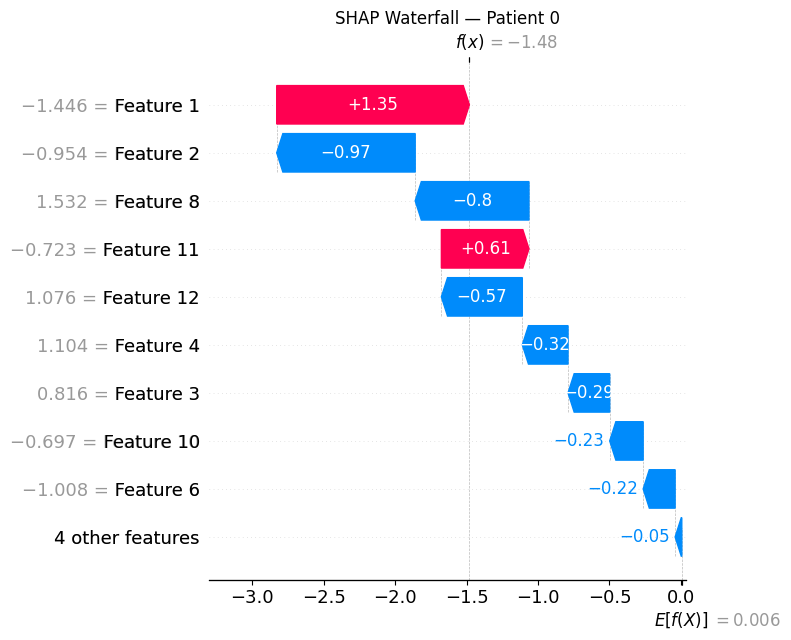

Waterfall plot saved!


In [5]:
# Waterfall plot for a single patient (first test sample)
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall — Patient 0')
plt.tight_layout()
plt.savefig('../report/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Waterfall plot saved!')

In [6]:
# Feature importance table
mean_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_shap})
importance_df = importance_df.sort_values('Mean |SHAP|', ascending=False)
print(importance_df.to_string(index=False))

 Feature  Mean |SHAP|
      cp     0.863634
     sex     0.767346
 thalach     0.715180
      ca     0.523221
   exang     0.516440
    thal     0.437702
 oldpeak     0.344883
trestbps     0.329024
   slope     0.300293
 restecg     0.211137
    chol     0.176576
     fbs     0.092111
     age     0.074418
